## 8. Paper Experiment 2 — Family Tree

The second experiment from Rumelhart, Hinton, and Williams (1986)
investigates whether a backpropagation network can learn useful
distributed representations for family relationships.

The network receives information about a person and a relationship
and learns to predict the corresponding person. The experiment is
particularly important because the network is tested on relationships
that were not explicitly included in its training examples.

The goal of this implementation is to reproduce the main idea of the
experiment using a manually implemented neural network and
backpropagation.



#### Import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#### Simple Family Tree

In [1]:
# People in our family tree
people = [
    "John",
    "Mary",
    "Bob",
    "Alice",
    "Tom",
    "Sara"
]

# Assign each person an index
person_to_index = {
    person: i
    for i, person in enumerate(people)
}

person_to_index

{'John': 0, 'Mary': 1, 'Bob': 2, 'Alice': 3, 'Tom': 4, 'Sara': 5}

#### State the relationships

In [2]:
relationships = [
    "father",
    "mother",
    "son",
    "daughter",
    "brother",
    "sister"
]

relationship_to_index = {
    relationship: i
    for i, relationship in enumerate(relationships)
}

relationship_to_index

{'father': 0, 'mother': 1, 'son': 2, 'daughter': 3, 'brother': 4, 'sister': 5}

#### Define family relationships

In [3]:
family_relations = [
    ("John", "father", "Bob"),
    ("John", "father", "Alice"),
    
    ("Mary", "mother", "Bob"),
    ("Mary", "mother", "Alice"),
    
    ("Bob", "son", "John"),
    ("Bob", "son", "Mary"),
    
    ("Alice", "daughter", "John"),
    ("Alice", "daughter", "Mary"),
    
    ("Bob", "brother", "Alice"),
    ("Alice", "sister", "Bob"),
    
    ("Tom", "son", "Bob"),
    ("Sara", "daughter", "Bob"),
]

#### Convert data into input/target pairs

In [5]:
def create_input(person, relationship):
    person_vector = np.zeros(len(people))
    relationship_vector = np.zeros(len(relationships))
    
    person_vector[person_to_index[person]] = 1
    relationship_vector[relationship_to_index[relationship]] = 1
    
    return np.concatenate([person_vector, relationship_vector])

In [6]:
example = create_input("John", "father")

print(example)
print("Input size:", len(example))

[1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
Input size: 12


#### Target Vector

In [7]:
def create_target(person):
    target = np.zeros(len(people))
    target[person_to_index[person]] = 1
    
    return target

In [8]:
target = create_target("Bob")

print(target)

[0. 0. 1. 0. 0. 0.]


#### Initialize the network

In [10]:
np.random.seed(42)

input_size = X_family.shape[1]
hidden_size = 8
output_size = Y_family.shape[1]

W1_family = np.random.uniform(
    -0.5, 0.5,
    (input_size, hidden_size)
)

b1_family = np.zeros((1, hidden_size))

W2_family = np.random.uniform(
    -0.5, 0.5,
    (hidden_size, output_size)
)

b2_family = np.zeros((1, output_size))

print("Input size:", input_size)
print("Hidden size:", hidden_size)
print("Output size:", output_size)

Input size: 12
Hidden size: 8
Output size: 6


#### Build X and Y

In [11]:
X_family = np.array([
    create_input(person, relationship)
    for person, relationship, answer in family_relations
])

Y_family = np.array([
    create_target(answer)
    for person, relationship, answer in family_relations
])

print("X shape:", X_family.shape)
print("Y shape:", Y_family.shape)

X shape: (12, 12)
Y shape: (12, 6)


#### Forward Propagation

In [12]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [13]:
def forward_family(X):
    z1 = X @ W1_family + b1_family
    a1 = sigmoid(z1)

    z2 = a1 @ W2_family + b2_family
    a2 = sigmoid(z2)

    return a1, a2

In [14]:
hidden_output, predictions_family = forward_family(X_family)

print("Hidden layer shape:", hidden_output.shape)
print("Output shape:", predictions_family.shape)

Hidden layer shape: (12, 8)
Output shape: (12, 6)


#### Back Propagation

In [15]:
learning_rate = 0.5
epochs = 10000

loss_history_family = []

for epoch in range(epochs):

    # -------------------------
    # Forward pass
    # -------------------------
    a1, a2 = forward_family(X_family)

    # -------------------------
    # Calculate loss
    # -------------------------
    loss = np.mean((a2 - Y_family) ** 2)
    loss_history_family.append(loss)

    # -------------------------
    # Output layer error
    # -------------------------
    delta2 = (
        (a2 - Y_family)
        * sigmoid_derivative(a2)
    )

    # Gradients for output layer
    dW2 = a1.T @ delta2
    db2 = np.sum(
        delta2,
        axis=0,
        keepdims=True
    )

    # -------------------------
    # Hidden layer error
    # -------------------------
    delta1 = (
        (delta2 @ W2_family.T)
        * sigmoid_derivative(a1)
    )

    # Gradients for hidden layer
    dW1 = X_family.T @ delta1
    db1 = np.sum(
        delta1,
        axis=0,
        keepdims=True
    )

    # -------------------------
    # Update weights
    # -------------------------
    W2_family -= learning_rate * dW2
    b2_family -= learning_rate * db2

    W1_family -= learning_rate * dW1
    b1_family -= learning_rate * db1

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch}: "
            f"Loss = {loss:.6f}"
        )

Epoch 0: Loss = 0.264177
Epoch 1000: Loss = 0.055647
Epoch 2000: Loss = 0.055597
Epoch 3000: Loss = 0.055582
Epoch 4000: Loss = 0.055575
Epoch 5000: Loss = 0.055571
Epoch 6000: Loss = 0.055568
Epoch 7000: Loss = 0.055566
Epoch 8000: Loss = 0.055565
Epoch 9000: Loss = 0.055564


#### Plot the loss

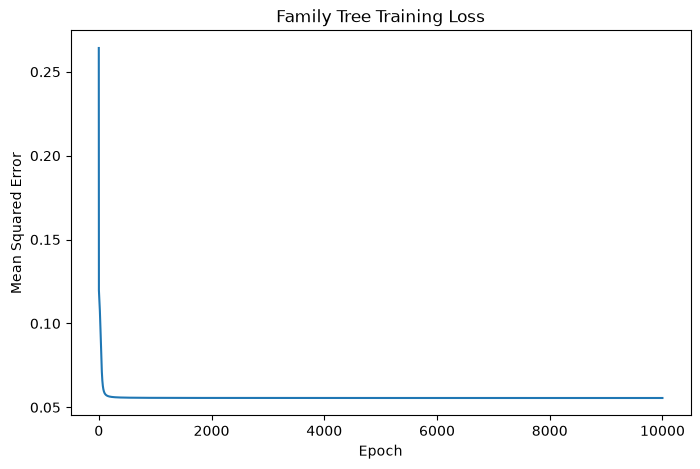

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history_family)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Family Tree Training Loss")

plt.show()

#### Make predcitions 

In [17]:
_, predictions_family = forward_family(X_family)

predicted_indices = np.argmax(
    predictions_family,
    axis=1
)

actual_indices = np.argmax(
    Y_family,
    axis=1
)

#### Convert predicitons back to names

In [18]:
index_to_person = {
    i: person
    for person, i in person_to_index.items()
}

index_to_person

for i, (person, relationship, answer) in enumerate(family_relations):

    predicted_person = index_to_person[
        predicted_indices[i]
    ]

    confidence = predictions_family[i][
        predicted_indices[i]
    ]

    print(
        f"{person} + {relationship} "
        f"→ Actual: {answer}, "
        f"Predicted: {predicted_person}, "
        f"Probability: {confidence:.4f}"
    )

John + father → Actual: Bob, Predicted: Bob, Probability: 0.5000
John + father → Actual: Alice, Predicted: Bob, Probability: 0.5000
Mary + mother → Actual: Bob, Predicted: Bob, Probability: 0.5000
Mary + mother → Actual: Alice, Predicted: Bob, Probability: 0.5000
Bob + son → Actual: John, Predicted: John, Probability: 0.5000
Bob + son → Actual: Mary, Predicted: John, Probability: 0.5000
Alice + daughter → Actual: John, Predicted: Mary, Probability: 0.5000
Alice + daughter → Actual: Mary, Predicted: Mary, Probability: 0.5000
Bob + brother → Actual: Alice, Predicted: Alice, Probability: 0.9913
Alice + sister → Actual: Bob, Predicted: Bob, Probability: 0.9944
Tom + son → Actual: Bob, Predicted: Bob, Probability: 0.9956
Sara + daughter → Actual: Bob, Predicted: Bob, Probability: 0.9944


#### Calculate Accuracy

In [19]:
accuracy_family = np.mean(
    predicted_indices == actual_indices
)

print(
    f"Family Tree Training Accuracy: "
    f"{accuracy_family:.4f}"
)

Family Tree Training Accuracy: 0.6667
